![image.png](attachment:image.png)

In [286]:
import pandas as pd
import numpy as np

df = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv', sep= ';', encoding='latin1')
df

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36898,159,10,2025,2025m10,35,4,Cachoeiras de Macacu,3300803,Interior,1,...,4.0,0.0,37,2,0,0,0,0,163,2
36899,165,10,2025,2025m10,33,5,Mangaratiba,3302601,Interior,1,...,4.0,0.0,21,0,0,0,0,0,196,2
36900,166,10,2025,2025m10,33,5,Angra dos Reis,3300100,Interior,3,...,12.0,0.0,82,8,0,1,0,0,682,2
36901,167,10,2025,2025m10,43,5,Paraty,3303807,Interior,1,...,2.0,1.0,11,1,0,0,0,0,195,2


In [287]:
df_furto_celular_dp = df.groupby('cisp')['furto_celular'].sum().reset_index()
df_furto_celular_dp =  df_furto_celular_dp.sort_values(by='furto_celular', ascending=False)
df_furto_celular_dp

,cisp,furto_celular
12,16,24879
2,5,23117
10,14,16945
8,12,16008
0,1,14968
...,...,...
87,104,72
77,92,63
131,157,55
114,138,52


In [288]:
array_furto_celular_dp = np.array(df_furto_celular_dp['furto_celular'])

In [289]:
media = np.mean(array_furto_celular_dp)
mediana = np.median(array_furto_celular_dp)
q1 = np.quantile(array_furto_celular_dp, 0.25)
q2 = np.quantile(array_furto_celular_dp, 0.50)
q3 = np.quantile(array_furto_celular_dp, 0.75)
#Distância = (média - mediana) / mediana
distancia = ((media - mediana)/mediana)
distanciaDEC = (distancia)*100
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
limite_inferior = q1 - 1.5 * iqr

print("A média é " +str(media))
print(f'A mediana é {mediana}')
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')

print(f"A distância é {distanciaDEC}")
print(f'O IQR é {iqr}')
print(f'O limite superior é {limite_superior}')
print(f'O limite inferior é {limite_inferior}') 
# quando o limite inferior for negativo, considerar como nao tendo outlier inferior


A média é 3338.1159420289855
A mediana é 1633.5
Primeiro quartil (Q1): 449.0
Segundo quartil (Q2, Mediana): 1633.5
Terceiro quartil (Q3): 4498.25
A distância é 104.35359302289473
O IQR é 4049.25
O limite superior é 10572.125
O limite inferior é -5624.875


In [290]:
outliers_furto_celular_dp = df_furto_celular_dp.loc[(df_furto_celular_dp['furto_celular'] > limite_superior) | (df_furto_celular_dp['furto_celular'] < limite_inferior)]
outliers_furto_celular_dp

,cisp,furto_celular
12,16,24879
2,5,23117
10,14,16945
8,12,16008
0,1,14968
5,9,14159
6,10,14105
1,4,13318
14,18,12939
28,32,12206


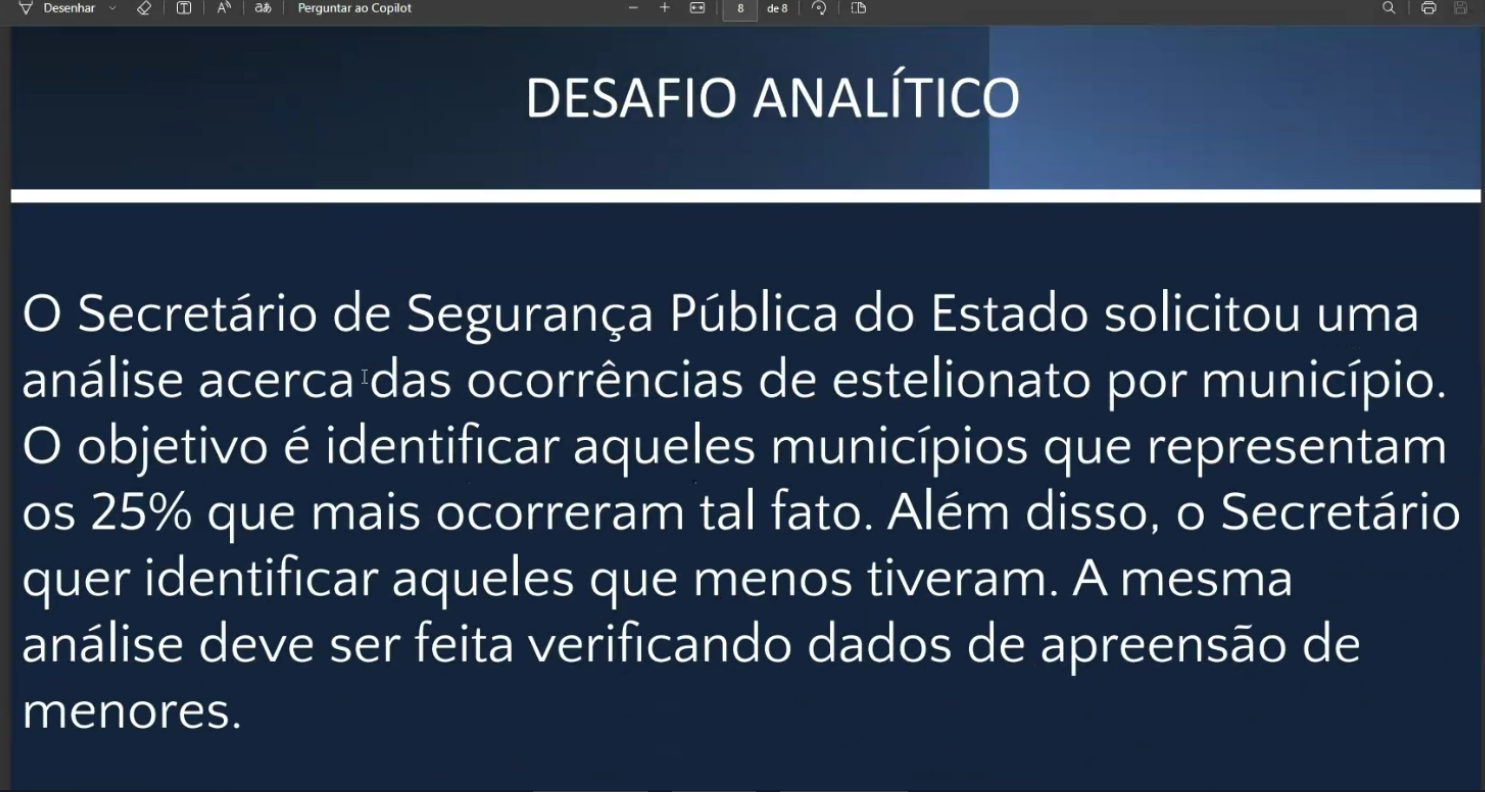

In [291]:
dfM = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/BaseMunicipioMensal.csv', sep= ';', encoding='latin1')
dfM

,fmun_cod,fmun,ano,mes,mes_ano,regiao,hom_doloso,lesao_corp_morte,latrocinio,cvli,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,3300100,Angra dos Reis,2014,1,2014m01,Interior,11,0,0,11,...,8,0,98,13,3,0,0,0,561,3
1,3300159,Aperibé,2014,1,2014m01,Interior,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
2,3300209,Araruama,2014,1,2014m01,Interior,2,0,0,2,...,5,0,91,10,1,0,0,0,480,3
3,3300225,Areal,2014,1,2014m01,Interior,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
4,3300233,Armação dos Búzios,2014,1,2014m01,Interior,2,0,0,2,...,3,2,46,0,0,0,0,0,309,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13060,3306008,Três Rios,2025,10,2025m10,Interior,3,0,0,3,...,22,0,68,3,0,0,0,0,536,2
13061,3306107,Valença,2025,10,2025m10,Interior,0,0,0,0,...,8,3,31,3,1,0,0,0,227,2
13062,3306156,Varre-Sai,2025,10,2025m10,Interior,0,0,0,0,...,1,0,5,0,0,0,0,0,20,2
13063,3306206,Vassouras,2025,10,2025m10,Interior,1,0,0,1,...,1,0,15,2,0,0,0,0,139,2


In [292]:
df_estelionato_dp = dfM.groupby('fmun')['estelionato'].sum().reset_index()
df_estelionato_dp =  df_estelionato_dp.sort_values(by='estelionato', ascending=False)
df_estelionato_dp

,fmun,estelionato
67,Rio de Janeiro,459529
47,Niterói,38230
24,Duque de Caxias,29747
49,Nova Iguaçu,28700
77,São Gonçalo,28425
...,...,...
35,Laje do Muriaé,126
16,Carapebus,124
89,Varre-Sai,102
83,São Sebastião do Alto,100


In [293]:
array_df_estelionato_dp = np.array(df_estelionato_dp['estelionato'])

In [294]:
media = np.mean(array_df_estelionato_dp)
mediana = np.median(array_df_estelionato_dp)
q1 = np.quantile(array_df_estelionato_dp, 0.25)
q2 = np.quantile(array_df_estelionato_dp, 0.50)
q3 = np.quantile(array_df_estelionato_dp, 0.75)

print("A média é " +str(media))
print(f'A mediana é {mediana}')
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')
#Distância = (média - mediana) / mediana
distancia = ((media - mediana)/mediana)
distanciaDEC = (distancia)*100
print(f"A distância é {distanciaDEC}")

A média é 9197.141304347826
A mediana é 1100.0
Primeiro quartil (Q1): 398.75
Segundo quartil (Q2, Mediana): 1100.0
Terceiro quartil (Q3): 5275.5
A distância é 736.1037549407115


In [295]:
munic_acima_q3 = df_estelionato_dp.loc[df_estelionato_dp['estelionato'] > q3]
munic_acima_q3

,fmun,estelionato
67,Rio de Janeiro,459529
47,Niterói,38230
24,Duque de Caxias,29747
49,Nova Iguaçu,28700
77,São Gonçalo,28425
14,Campos dos Goytacazes,18605
81,São João de Meriti,18575
36,Macaé,14653
54,Petrópolis,13907
8,Belford Roxo,13147


In [296]:
munic_acima_q1 = df_estelionato_dp.loc[df_estelionato_dp['estelionato'] < q1]
munic_acima_q1

,fmun,estelionato
79,São José do Vale do Rio Preto,365
64,Rio Claro,364
57,Porciúncula,356
45,Natividade,338
23,Duas Barras,299
13,Cambuci,293
25,Engenheiro Paulo de Frontin,290
74,Sumidouro,270
65,Rio das Flores,219
30,Italva,217


In [297]:
#CRIME APREENSAO MENORES

df_aaapai_dp = dfM.groupby('fmun')['aaapai'].sum().reset_index()
df_aaapai_dp =  df_aaapai_dp.sort_values(by='aaapai', ascending=False)
df_aaapai_dp

,fmun,aaapai
67,Rio de Janeiro,29142
77,São Gonçalo,4154
14,Campos dos Goytacazes,3377
24,Duque de Caxias,3017
47,Niterói,2722
...,...,...
37,Macuco,7
3,Areal,5
65,Rio das Flores,5
89,Varre-Sai,5


In [298]:
array_df_aaapai_dp = np.array(df_aaapai_dp['aaapai'])

In [299]:
media = np.mean(array_df_aaapai_dp)
mediana = np.median(array_df_aaapai_dp)
q1 = np.quantile(array_df_aaapai_dp, 0.25)
q2 = np.quantile(array_df_aaapai_dp, 0.50)
q3 = np.quantile(array_df_aaapai_dp, 0.75)

print("A média é " +str(media))
print(f'A mediana é {mediana}')
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')
#Distância = (média - mediana) / mediana
distancia = ((media - mediana)/mediana)
distanciaDEC = (distancia)*100
print(f"A distância é {distanciaDEC}")

A média é 832.8152173913044
A mediana é 193.5
Primeiro quartil (Q1): 39.0
Segundo quartil (Q2, Mediana): 193.5
Terceiro quartil (Q3): 705.75
A distância é 330.3954611841366


In [300]:
municaaapai_acima_q3 = df_aaapai_dp.loc[df_aaapai_dp['aaapai'] > q3]
municaaapai_acima_q3

,fmun,aaapai
67,Rio de Janeiro,29142
77,São Gonçalo,4154
14,Campos dos Goytacazes,3377
24,Duque de Caxias,3017
47,Niterói,2722
49,Nova Iguaçu,2560
11,Cabo Frio,2503
81,São João de Meriti,2101
91,Volta Redonda,1647
48,Nova Friburgo,1566


In [301]:
municaaapai_acima_q1 = df_aaapai_dp.loc[df_aaapai_dp['aaapai'] < q1]
municaaapai_acima_q1

,fmun,aaapai
70,Sapucaia,36
13,Cambuci,28
23,Duas Barras,27
64,Rio Claro,26
53,Paty do Alferes,22
17,Cardoso Moreira,21
16,Carapebus,21
25,Engenheiro Paulo de Frontin,21
20,Comendador Levy Gasparian,21
30,Italva,20


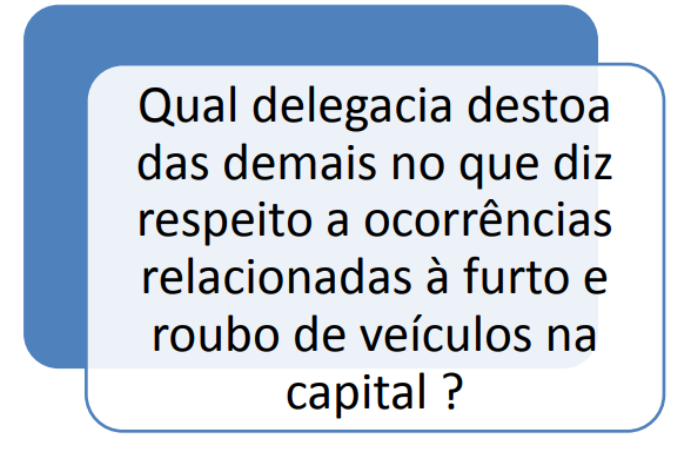

In [302]:
## 📥 2. Carregamento dos Dados

try:
    # Carregando o arquivo diretamente do link
    # O arquivo utiliza ';' como separador (sep=';') e a codificação 'latin1'
    df = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv',sep=';')
    print("✅ Dados carregados com sucesso!")
    display(df)

except Exception as e:
    # Captura outros erros além de FileNotFoundError, como problemas de conexão ou formatação
    print(f"❌ Erro ao carregar o arquivo: {e}")

✅ Dados carregados com sucesso!


,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36898,159,10,2025,2025m10,35,4,Cachoeiras de Macacu,3300803,Interior,1,...,4.0,0.0,37,2,0,0,0,0,163,2
36899,165,10,2025,2025m10,33,5,Mangaratiba,3302601,Interior,1,...,4.0,0.0,21,0,0,0,0,0,196,2
36900,166,10,2025,2025m10,33,5,Angra dos Reis,3300100,Interior,3,...,12.0,0.0,82,8,0,1,0,0,682,2
36901,167,10,2025,2025m10,43,5,Paraty,3303807,Interior,1,...,2.0,1.0,11,1,0,0,0,0,195,2


In [303]:
df.columns

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [304]:
df['roubo_furto_veiculo']= df['furto_veiculos']+ df['roubo_veiculo']
df_capital = df.loc[df['regiao']== "Capital"]
df_capital#[['cisp','ano', 'mes','regiao','munic','furto_veiculos','roubo_veiculo','roubo_furto_veiculo']]



,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,roubo_furto_veiculo
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,21,2,0,0,0,0,578,3,17
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,15,6,0,1,0,0,441,3,18
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,47,2,1,0,0,0,637,3,39
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,26,2,1,0,0,0,473,3,44
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,10,1,3,0,0,0,147,3,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36802,40,10,2025,2025m10,9,2,Rio de Janeiro,3304557,Capital,4,...,0.0,25,5,1,0,0,0,628,2,69
36803,41,10,2025,2025m10,18,2,Rio de Janeiro,3304557,Capital,0,...,0.0,49,0,0,0,0,0,856,2,35
36804,42,10,2025,2025m10,31,2,Rio de Janeiro,3304557,Capital,3,...,2.0,102,6,3,0,0,0,1450,2,79
36805,43,10,2025,2025m10,27,2,Rio de Janeiro,3304557,Capital,2,...,1.0,110,13,1,0,0,0,691,2,22


In [305]:
df_veiculo_capital = df_capital.groupby('cisp')['roubo_furto_veiculo'].sum().reset_index()
df_veiculo_capital =  df_veiculo_capital.sort_values(by='roubo_furto_veiculo', ascending=False)
df_veiculo_capital

,cisp,roubo_furto_veiculo
23,27,39024
30,34,36897
31,35,33436
35,39,32500
34,38,25999
29,33,25899
17,21,25267
18,22,22896
36,40,22451
25,29,21722


In [306]:
array_df_veiculo_capital = np.array(df_veiculo_capital['roubo_furto_veiculo'])

In [307]:
media = np.mean(array_df_veiculo_capital)
mediana = np.median(array_df_veiculo_capital)
q1 = np.quantile(array_df_veiculo_capital, 0.25)
q2 = np.quantile(array_df_veiculo_capital, 0.50)
q3 = np.quantile(array_df_veiculo_capital, 0.75)
#Distância = (média - mediana) / mediana
distancia = ((media - mediana)/mediana)
distanciaDEC = (distancia)*100
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
limite_inferior = q1 - 1.5 * iqr

print("A média é " +str(media))
print(f'A mediana é {mediana}')
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')

print(f"A distância é {distanciaDEC}")
print(f'O IQR é {iqr}')
print(f'O limite superior é {limite_superior}')
print(f'O limite inferior é {limite_inferior}') 
# quando o limite inferior for negativo, considerar como nao tendo outlier inferior

A média é 13949.333333333334
A mediana é 12701.0
Primeiro quartil (Q1): 5015.25
Segundo quartil (Q2, Mediana): 12701.0
Terceiro quartil (Q3): 18068.75
A distância é 9.8286224181823
O IQR é 13053.5
O limite superior é 37649.0
O limite inferior é -14565.0


In [308]:
media = np.mean(array_df_veiculo_capital)
mediana = np.median(array_df_veiculo_capital)
q1 = np.quantile(array_df_veiculo_capital, 0.25)
q2 = np.quantile(array_df_veiculo_capital, 0.50)
q3 = np.quantile(array_df_veiculo_capital, 0.75)
#Distância = (média - mediana) / mediana
distancia = ((media - mediana)/mediana)
distanciaDEC = (distancia)*100
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
limite_inferior = q1 - 1.5 * iqr

print("A média é " +str(media))
print(f'A mediana é {mediana}')
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')

print(f"A distância é {distanciaDEC}")
print(f'O IQR é {iqr}')
print(f'O limite superior é {limite_superior}')
print(f'O limite inferior é {limite_inferior}') 
# quando o limite inferior for negativo, considerar como nao tendo outlier inferior

A média é 13949.333333333334
A mediana é 12701.0
Primeiro quartil (Q1): 5015.25
Segundo quartil (Q2, Mediana): 12701.0
Terceiro quartil (Q3): 18068.75
A distância é 9.8286224181823
O IQR é 13053.5
O limite superior é 37649.0
O limite inferior é -14565.0


In [309]:
outliers_df_veiculo_capital = df_veiculo_capital.loc[(df_veiculo_capital['roubo_furto_veiculo'] > limite_superior) | (df_veiculo_capital['roubo_furto_veiculo'] < limite_inferior)]
outliers_df_veiculo_capital

,cisp,roubo_furto_veiculo
23,27,39024


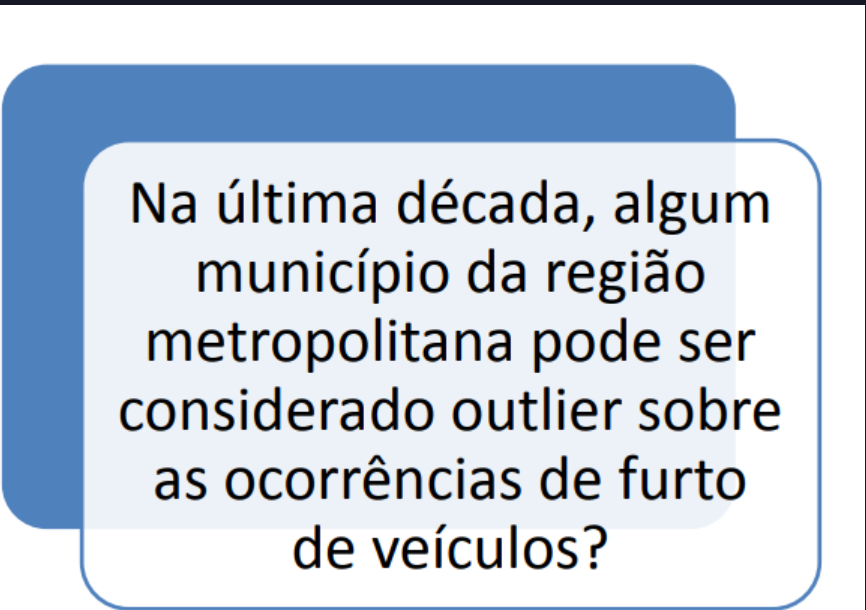

In [310]:
## 📥 2. Carregamento dos Dados

try:
    # Carregando o arquivo diretamente do link
    # O arquivo utiliza ';' como separador (sep=';') e a codificação 'latin1'
   df = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/BaseMunicipioMensal.csv', sep= ';', encoding='latin1')
   print("✅ Dados carregados com sucesso!")
   #colunas_principais = ['fmun', 'ano', 'furto_veiculos']
   display (df[["fmun", "ano", "furto_veiculos"]])
    

except Exception as e:
    # Captura outros erros além de FileNotFoundError, como problemas de conexão ou formatação
    print(f"❌ Erro ao carregar o arquivo: {e}")

✅ Dados carregados com sucesso!


,fmun,ano,furto_veiculos
0,Angra dos Reis,2014,18
1,Aperibé,2014,0
2,Araruama,2014,16
3,Areal,2014,0
4,Armação dos Búzios,2014,9
...,...,...,...
13060,Três Rios,2025,1
13061,Valença,2025,0
13062,Varre-Sai,2025,0
13063,Vassouras,2025,0


In [311]:
#Lista dos municipios da regiao metropolitana
municipios_rmrj = [
    "Rio de Janeiro", "Belford Roxo", "Duque de Caxias", "Guapimirim", "Itaboraí", "Japeri", "Magé",
    "Maricá", "Mesquita", "Nilópolis", "Niterói", "Nova Iguaçu", "Paracambi", "Queimados",
    "São Gonçalo", "São João de Meriti", "Seropédica", "Tanguá", "Cachoeiras de Macacu",
    "Rio Bonito", "Itaguaí", "Petrópolis"]

In [312]:
## Filtra os municípios da lista, deve usar o (.isin()) para relacionar com uma variavel criada
df_veiculo_metropole = df.loc[(df['fmun'].isin(municipios_rmrj))] 
df_veiculo_metropole = df_veiculo_metropole.loc[(df_veiculo_metropole[('ano')]  >= 2015 )]
#df_veiculo_metropole = (df['fmun'].isin(municipios_rmrj)) & (df['ano'] >= 2015) (forma mais pratica)
# Agrupa por município e soma os furtos
df_veiculo_metropole = df_veiculo_metropole.groupby('fmun')['furto_veiculos'].sum().reset_index()
df_veiculo_metropole =  df_veiculo_metropole.sort_values(by='furto_veiculos', ascending = False)
df_veiculo_metropole

,fmun,furto_veiculos
17,Rio de Janeiro,78688
19,São Gonçalo,12459
2,Duque de Caxias,11506
12,Nova Iguaçu,10269
11,Niterói,7339
20,São João de Meriti,5858
0,Belford Roxo,4404
9,Mesquita,2479
7,Magé,2433
4,Itaboraí,2407


In [313]:
# 1. Calcular Q1 (1º Quartil - 25º Percentil) e Q3 (3º Quartil - 75º Percentil)
Q1 = df_veiculo_metropole['furto_veiculos'].quantile(0.25)
Q3 = df_veiculo_metropole['furto_veiculos'].quantile(0.75)

# 2. Calcular o Intervalo Interquartil (IQR)
IQR = Q3 - Q1

# 3. Definir os limites (Upper e Lower Bound)
# Um outlier é geralmente definido como 1.5 * IQR acima de Q3 ou abaixo de Q1
limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

# 4. Filtrar os municípios que são considerados outliers
outliers = df_veiculo_metropole[
    (df_veiculo_metropole['furto_veiculos'] > limite_superior) | 
    (df_veiculo_metropole['furto_veiculos'] < limite_inferior)
]

print("\n--- Resultados da Análise de Outliers ---")
print(f"Q1 (25% dos municípios estão abaixo): {Q1:,.0f}")
print(f"Q3 (75% dos municípios estão abaixo): {Q3:,.0f}")
print(f"Limite Superior para Outlier (Q3 + 1.5*IQR): {limite_superior:,.0f}")
print("-" * 35)

if outliers.empty:
    print("✅ Nenhum município da Região Metropolitana foi identificado como outlier pelo método IQR.")
else:
    print("🚨 Municípios Considerados Outliers:")
    print(outliers.sort_values(by='furto_veiculos', ascending=False))


--- Resultados da Análise de Outliers ---
Q1 (25% dos municípios estão abaixo): 722
Q3 (75% dos municípios estão abaixo): 5,494
Limite Superior para Outlier (Q3 + 1.5*IQR): 12,654
-----------------------------------
🚨 Municípios Considerados Outliers:
              fmun  furto_veiculos
17  Rio de Janeiro           78688


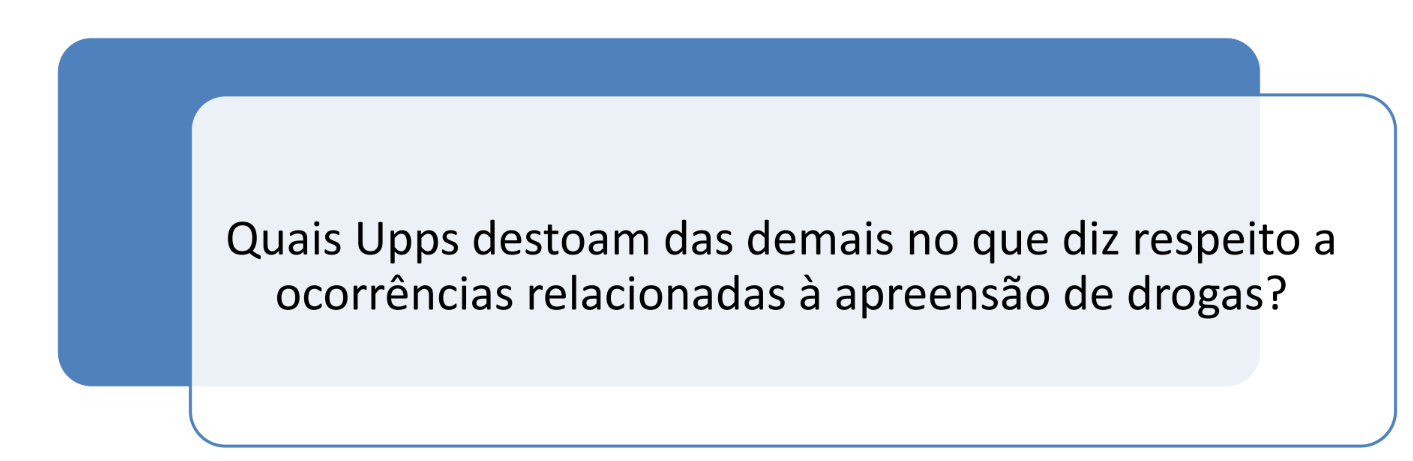

In [314]:
df = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/UppEvolucaoMensalDeTitulos.csv', sep=';', encoding='latin1')
df

,cod_upp,upp,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,hom_por_interv_policial,tentat_hom,lesao_corp_dolosa,...,armas_apreendidas,cump_mandado_prisao,ocorr_flagrante,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias
0,1,Santa Marta,2007,1,0,0,0,0,0,1,...,2,1,0,0,0,0,0,0,0,11
1,2,Cidade de Deus,2007,1,3,0,0,0,1,18,...,7,2,11,7,2,0,0,0,0,98
2,3,Batam,2007,1,0,0,0,0,0,4,...,0,0,0,1,0,0,0,0,0,19
3,4,Chapéu Mangueira / Babilônia,2007,1,0,0,0,0,0,1,...,0,2,0,1,0,0,0,0,0,9
4,5,Pavão-Pavãozinho,2007,1,0,0,0,0,0,4,...,0,0,0,1,1,0,0,0,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7975,34,Arará / Mandela,2024,6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7976,35,Lins,2024,6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7977,36,Camarista Méier,2024,6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7978,37,Mangueirinha,2024,6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_upp_drogas = df.groupby('upp')['apreensao_drogas'].sum().reset_index()
df_upp_drogas =  df_upp_drogas.sort_values(by='apreensao_drogas', ascending = False)
df_upp_drogas

,upp,apreensao_drogas
12,Cidade de Deus,2818
37,Vila Kennedy,1363
18,Jacarezinho,1132
21,Mangueira,774
27,Providência,716
26,Pavão-Pavãozinho,655
28,Rocinha,636
4,Barreira do Vasco / Tuiuti,627
20,Macacos,618
3,Arará / Mandela,598


In [316]:
array_upp = np.array(df_upp_drogas['apreensao_drogas'])
media_upp = np.mean(array_upp)
mediana_upp = np.median(array_upp)
q1_upp = np.quantile(array_upp, 0.25)
q2_upp = np.quantile(array_upp, 0.50)
q3_upp = np.quantile(array_upp, 0.75)
distancia_upp = (media_upp-mediana_upp)/ mediana_upp
iqr_upp = q3_upp - q1_upp
limite_superior_upp = q3_upp + 1.5 * iqr_upp
limite_inferior_upp = q1_upp - 1.5 * iqr_upp

In [317]:
print(f'A média é {media_upp}')
print(f'A mediana é {mediana_upp}')
print(f'Primeiro quartil (Q1): {q1_upp}')
print(f'Segundo quartil (Q2, Mediana): {q2_upp}')
print(f'Terceiro quartil (Q3): {q3_upp}')
print(f'a distancia entre a média e a mediana é: {distancia_upp}')
print(f'o valor do limite superior é: {limite_superior_upp}')
print(f'o valor do limite inferior é: {limite_inferior_upp}')

A média é 508.05263157894734
A mediana é 402.0
Primeiro quartil (Q1): 263.0
Segundo quartil (Q2, Mediana): 402.0
Terceiro quartil (Q3): 596.0
a distancia entre a média e a mediana é: 0.26381251636554065
o valor do limite superior é: 1095.5
o valor do limite inferior é: -236.5


In [318]:
outliers_upp = df_upp_drogas.loc[df_upp_drogas['apreensao_drogas'] > limite_superior_upp]
outliers_upp 

,upp,apreensao_drogas
12,Cidade de Deus,2818
37,Vila Kennedy,1363
18,Jacarezinho,1132


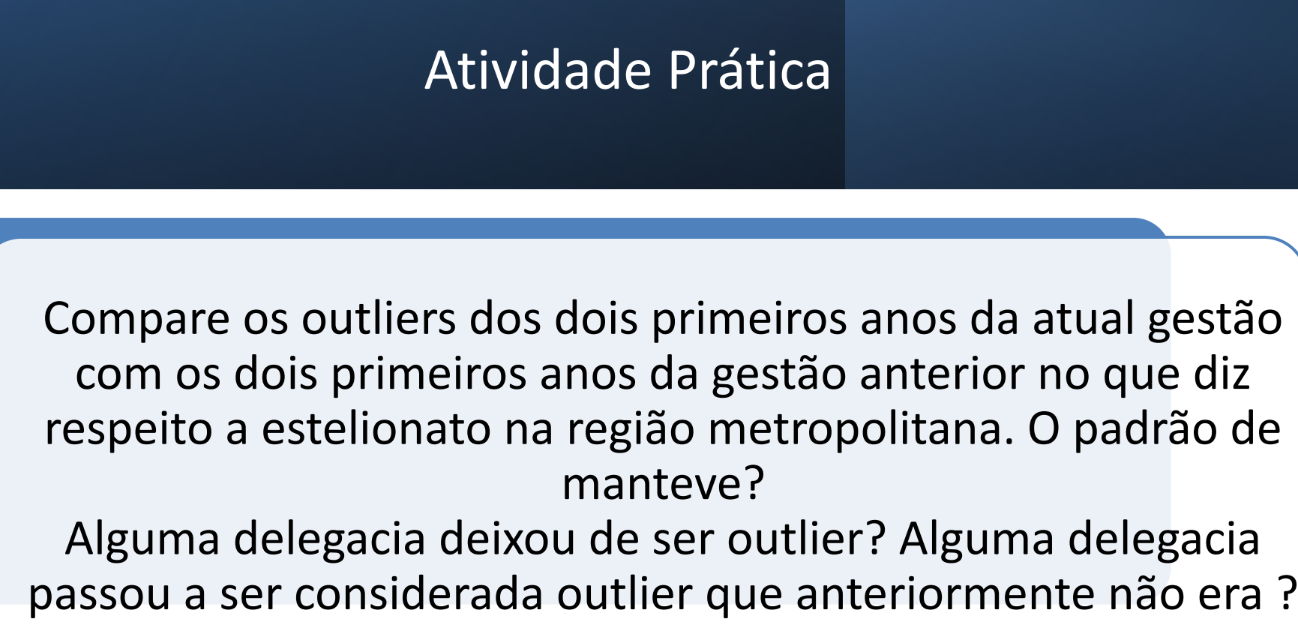